<a href="https://colab.research.google.com/github/shruti-2562/FML/blob/main/prac2_FML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix

data = {
"Age":[22,24,25,26,28,30,32,34,35,36,38,40,42,44,45,46,48,50,52,55],
"Income":[25000,27000,30000,32000,35000,40000,45000,48000,50000,53000,56000,60000,65000,68000,70000,73000,76000,80000,85000,90000],
"PurchaseAmount":[1200,1400,1600,1800,2100,2500,3000,3300,3600,3900,4300,4700,5200,5600,6000,6400,6900,7400,8000,8600],

"Purchased":[0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
}

df = pd.DataFrame(data)

print("\nCustomer Dataset\n")
print(df)

X = df[["Age","Income"]]

y_reg = df["PurchaseAmount"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
X, y_reg, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)

y_cls = df["Purchased"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

logistic_model = LogisticRegression()
logistic_model.fit(X_train_cls, y_train_cls)

age = int(input("\nEnter Customer Age: "))
income = float(input("Enter Customer Income: "))

new_customer = pd.DataFrame({
"Age":[age],
"Income":[income]
})

predicted_amount = linear_model.predict(new_customer)

print("\n========== LINEAR REGRESSION ==========")
print("Predicted Purchase Amount = ₹", round(predicted_amount[0],2))

purchase = logistic_model.predict(new_customer)

print("\n========== LOGISTIC REGRESSION ==========")

if purchase[0] == 1:
    print("Customer is Likely to Purchase")
else:
    print("Customer is Not Likely to Purchase")

y_pred_reg = linear_model.predict(X_test_reg)

print("\n========== LINEAR REGRESSION PERFORMANCE ==========")
print("MAE :", round(mean_absolute_error(y_test_reg, y_pred_reg),2))
print("MSE :", round(mean_squared_error(y_test_reg, y_pred_reg),2))
print("R2 Score :", round(r2_score(y_test_reg, y_pred_reg),2))

y_pred_cls = logistic_model.predict(X_test_cls)

print("\n========== LOGISTIC REGRESSION PERFORMANCE ==========")
print("Accuracy :", round(accuracy_score(y_test_cls, y_pred_cls),2))

print("\nConfusion Matrix")
print(confusion_matrix(y_test_cls, y_pred_cls))


Customer Dataset

    Age  Income  PurchaseAmount  Purchased
0    22   25000            1200          0
1    24   27000            1400          0
2    25   30000            1600          0
3    26   32000            1800          0
4    28   35000            2100          0
5    30   40000            2500          1
6    32   45000            3000          1
7    34   48000            3300          1
8    35   50000            3600          1
9    36   53000            3900          1
10   38   56000            4300          1
11   40   60000            4700          1
12   42   65000            5200          1
13   44   68000            5600          1
14   45   70000            6000          1
15   46   73000            6400          1
16   48   76000            6900          1
17   50   80000            7400          1
18   52   85000            8000          1
19   55   90000            8600          1

Enter Customer Age: 25
Enter Customer Income: 1800

========== LINEAR REGRESS

Upload customer_purchase_dataset.csv


Saving customer_purchase_dataset.csv to customer_purchase_dataset (4).csv
   CustomerID  Age  Income  YearsAsCustomer  StoreVisitsPerMonth  \
0           1   60   39000                1                    9   
1           2   34   42000               12                    4   
2           3   25  100000                7                    2   
3           4   25   52000                4                   17   
4           5   55   50000               12                   18   

   PurchaseAmount  Purchased  
0            3555          1  
1            3880          1  
2            5930          1  
3            4907          1  
4            6039          1  
    CustomerID  Age  Income  YearsAsCustomer  StoreVisitsPerMonth  \
95          96   58   90000                2                   13   
96          97   32   57000                1                   14   
97          98   53   93000               11                    7   
98          99   47   33000               11           

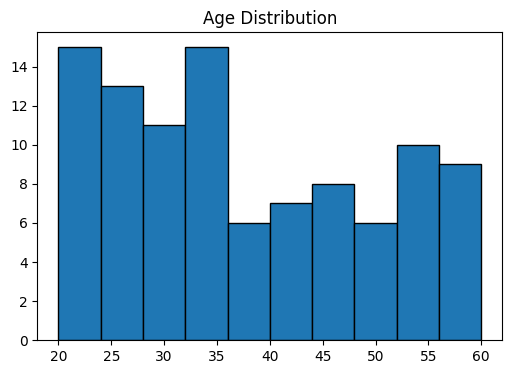

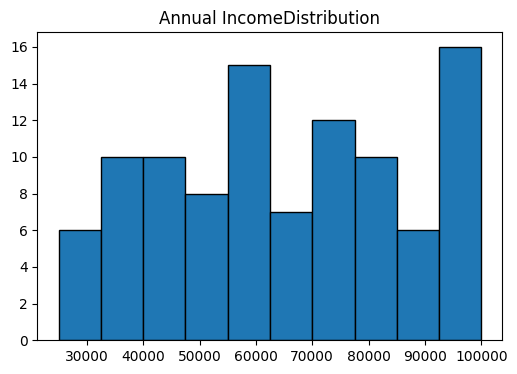

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   CustomerID           100 non-null    int64
 1   Age                  100 non-null    int64
 2   Income               100 non-null    int64
 3   YearsAsCustomer      100 non-null    int64
 4   StoreVisitsPerMonth  100 non-null    int64
 5   PurchaseAmount       100 non-null    int64
 6   Purchased            100 non-null    int64
dtypes: int64(7)
memory usage: 5.6 KB


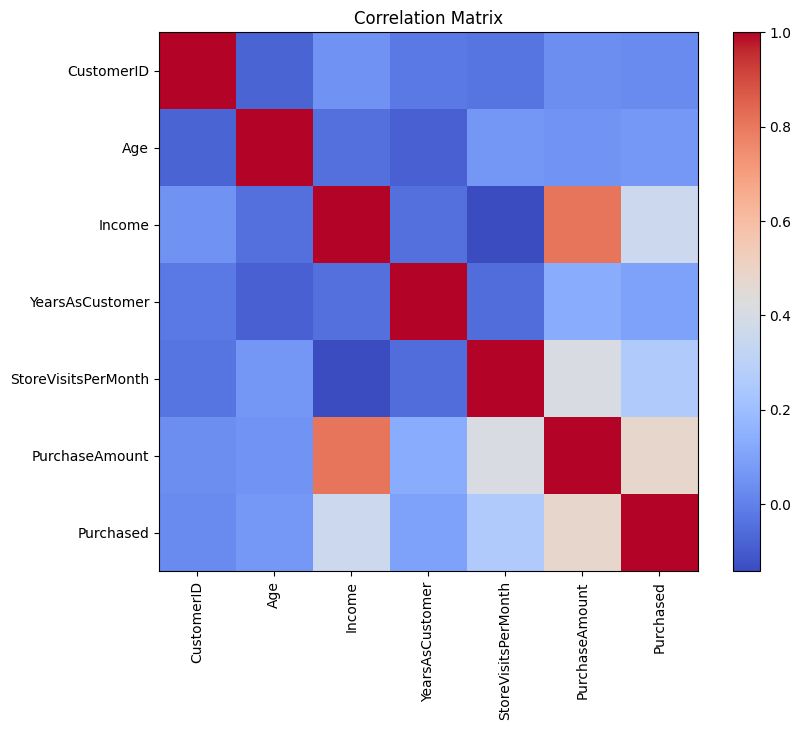

Enter Age: 25
Enter Annual Income: 52000
Enter Years As Customer: 7
Enter Store Visits Per Month: 2
Predicted Purchase Amount: 3502.77
Purchase Status: Purchased
MAE: 159.3096618730109
MSE: 34638.15825591994
R2 Score: 0.9747098932112853
Accuracy: 1.0
[[ 1  0]
 [ 0 19]]


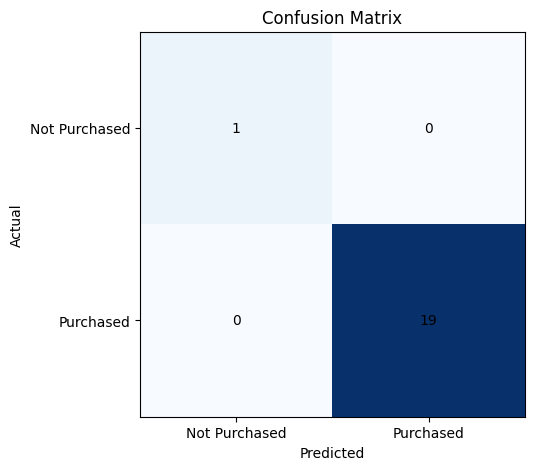

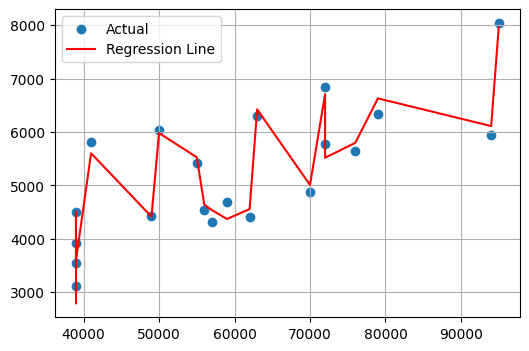

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import \
mean_absolute_error,mean_squared_error,r2_score,accuracy_score,confusion_matrix

print("Upload customer_purchase_dataset.csv")
uploaded=files.upload()
df=pd.read_csv("customer_purchase_dataset.csv")

print(df.head())
print(df.tail())
print(df.info())
print(df.describe())
print(df.isnull().sum())

plt.figure(figsize=(6,4)); plt.hist(df["Age"],bins=10,edgecolor="black"); plt.title("Age Distribution");
plt.show()
plt.figure(figsize=(6,4)); plt.hist(df["Income"],bins=10,edgecolor="black"); plt.title("Annual Income\
Distribution"); plt.show()
# Removed plots and encoding for 'Gender', 'City', 'Occupation', 'MembershipType' as they are not in
df.info()
# plt.figure(figsize=(6,4)); plt.scatter(df["Income"],df["PurchaseAmount"]); plt.xlabel("Income");
# plt.ylabel("PurchaseAmount"); plt.grid(); plt.show()
# plt.figure(figsize=(6,4)); plt.scatter(df["StoreVisitsPerMonth"],df["PurchaseAmount"]);
# plt.xlabel("StoreVisitsPerMonth"); plt.ylabel("PurchaseAmount"); plt.grid(); plt.show()

# for c in ["Gender","City","Occupation","MembershipType"]:
#     df[c]=LabelEncoder().fit_transform(df[c])

corr=df.corr(numeric_only=True)
plt.figure(figsize=(9,7))
plt.imshow(corr,cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("Correlation Matrix")
plt.show()

X=df[["Age","Income","YearsAsCustomer","StoreVisitsPerMonth"]]
yr=df["PurchaseAmount"]
yc=df["Purchased"]

X_train,X_test,y_train,y_test=train_test_split(X,yr,test_size=0.2,random_state=42)
X_train1,X_test1,y_train1,y_test1=train_test_split(X,yc,test_size=0.2,random_state=42,stratify=yc)

lr=LinearRegression(); lr.fit(X_train,y_train)
log=LogisticRegression(max_iter=1000); log.fit(X_train1,y_train1)

age=int(input("Enter Age: "))
income=float(input("Enter Annual Income: "))
years=int(input("Enter Years As Customer: "))
store=int(input("Enter Store Visits Per Month: "))
# Removed input prompts for non-existent columns: OnlinePurchasesPerMonth, DiscountUsed,
# AverageBasketValue
# online=int(input("Enter Online Purchases Per Month: "))

# discount=float(input("Enter Discount Used: "))
# basket=float(input("Enter Average Basket Value: "))

new=pd.DataFrame({"Age":[age],"Income":[income],"YearsAsCustomer":[years],
"StoreVisitsPerMonth":[store]}) # Updated new DataFrame to only include existing columns

print("Predicted Purchase Amount:",round(lr.predict(new)[0],2))
print("Purchase Status:","Purchased" if log.predict(new)[0]==1 else "Not Purchased")

pred=lr.predict(X_test)
print("MAE:",mean_absolute_error(y_test,pred))
print("MSE:",mean_squared_error(y_test,pred))
print("R2 Score:",r2_score(y_test,pred))

cp=log.predict(X_test1)
print("Accuracy:",accuracy_score(y_test1,cp))
cm=confusion_matrix(y_test1,cp)
print(cm)

plt.figure(figsize=(5,5))
plt.imshow(cm,cmap="Blues")
plt.xticks([0,1],["Not Purchased","Purchased"])
plt.yticks([0,1],["Not Purchased","Purchased"])
for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),ha="center",va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

idx=np.argsort(X_test["Income"].values)
plt.figure(figsize=(6,4))
plt.scatter(X_test["Income"],y_test,label="Actual")
plt.plot(X_test["Income"].values[idx],pred[idx],color="red",label="Regression Line")
plt.legend()
plt.grid()
plt.show()